# Targeted EDA for Music Discovery Engine

This notebook is designed to answer the **highest-risk data questions** for the current architecture, not just do generic EDA.

## Core goals
1. Verify whether the **data pipeline** matches the current triplet-learning setup
2. Quantify **triplet quality issues** (degenerate positives, false negatives, easy negatives)
3. Check whether **train/eval splits** reflect true future generalization
4. Measure how much of the **catalog is actually supervised** by user behavior
5. Audit whether downstream modeling assumptions still hold after the MLP embedding step

## Recommended reading order
- Run the notebook top to bottom once
- Focus first on sections 3, 4, and 5
- Treat the final summary table as the decision checkpoint before further model tuning


In [47]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

ROOT = Path('..') if Path.cwd().name == 'notebooks' else Path('.')
PROCESSED = ROOT / 'data' / 'processed'
RAW = ROOT / 'data' / 'raw'

TRACK_PATH = PROCESSED / 'track_features.parquet'
TRIPLET_PATH = PROCESSED / 'triplets.parquet'
HISTORY_PATH = PROCESSED / 'user_history.parquet'
LASTFM_PATH = RAW / 'lastfm-dataset-1K' / 'userid-timestamp-artid-artname-traid-traname.tsv'

GAP_MINUTES = 30
MIN_SESSION_LENGTH = 2
LOAD_RAW_EVENTS = True   # set False if you only want processed-data EDA
RAW_NROWS = 1_000_000    # set to None for full raw load if your machine can handle it


## 1) Load processed data


In [48]:
track_df = pd.read_parquet(TRACK_PATH)
triplets_df = pd.read_parquet(TRIPLET_PATH)
history_df = pd.read_parquet(HISTORY_PATH)

print('track_df', track_df.shape)
print('triplets_df', triplets_df.shape)
print('history_df', history_df.shape)

display(track_df.head())
display(triplets_df.head())
display(history_df.head())

track_df (80629, 12)
triplets_df (688071, 4)
history_df (1341891, 4)


,artist_norm,track_norm,danceability,energy,loudness_norm,acousticness,instrumentalness,liveness,valence,tempo_norm,speechiness,arousal
0,gen hoshino,comedy,0.6760,0.4610,0.8876,0.0322,0.0000,0.3580,0.7150,0.2662,0.1430,0.5685
1,ben woodward,ghost - acoustic,0.4200,0.1660,0.7127,0.9240,0.0000,0.1010,0.2670,0.2083,0.0763,0.2930
2,ingrid michaelson;zayn,to begin again,0.4380,0.3590,0.8378,0.2100,0.0000,0.1170,0.1200,0.2018,0.0557,0.3985
3,kina grannis,can't help falling in love,0.3550,0.1013,0.7503,0.9150,0.0001,0.1250,0.1375,0.5613,0.0333,0.2281
4,chord overstreet,hold on,0.6135,0.4430,0.8387,0.4690,0.0000,0.0829,0.1665,0.4442,0.0536,0.5282


,user_id,anchor_idx,pos_idx,neg_idx
0,user_000001,78683,78353,36911
1,user_000001,3399,78683,75953
2,user_000001,3681,3399,41628
3,user_000001,3399,78353,35869
4,user_000001,78353,78683,21728


,user_id,track_idx,split,is_discovery
0,user_000001,78683,train,False
1,user_000001,3399,train,False
2,user_000001,3681,train,False
3,user_000001,3399,train,False
4,user_000001,3399,train,False


In [49]:
summary = pd.DataFrame({
    'rows': [len(track_df), len(triplets_df), len(history_df)],
    'columns': [track_df.shape[1], triplets_df.shape[1], history_df.shape[1]],
}, index=['track_features', 'triplets', 'user_history'])
display(summary)

,rows,columns
track_features,80629,12
triplets,688071,4
user_history,1341891,4


## 2) Optional raw Last.fm load for join/session coverage
This section helps answer whether the processed data discarded a large amount of behavior before training ever starts.


In [50]:
TSV_COLS = ['user_id', 'timestamp', 'artist_id', 'artist_name', 'track_id', 'track_name']

if LOAD_RAW_EVENTS:
    raw_df = pd.read_csv(
        LASTFM_PATH,
        sep='\t',
        header=None,
        names=TSV_COLS,
        nrows=RAW_NROWS,
        on_bad_lines='skip',
    )
    raw_df['timestamp'] = pd.to_datetime(raw_df['timestamp'], utc=True, errors='coerce')
    raw_df = raw_df.dropna(subset=['user_id', 'timestamp', 'artist_name', 'track_name']).copy()
    raw_df['artist_norm'] = raw_df['artist_name'].str.lower().str.strip()
    raw_df['track_norm'] = raw_df['track_name'].str.lower().str.strip()
    print('raw_df', raw_df.shape)
    display(raw_df.head())
else:
    raw_df = None
    print('Skipping raw-event analysis.')

raw_df (1000000, 8)


,user_id,timestamp,artist_id,artist_name,track_id,track_name,artist_norm,track_norm
0,user_000001,2009-05-04 23:08:57+00:00,f1b1cf71-bd35-4e99-8624-24a6e15f133a,Deep Dish,NaN,Fuck Me Im Famous (Pacha Ibiza)-09-28-2007,deep dish,fuck me im famous (pacha ibiza)-09-28-2007
1,user_000001,2009-05-04 13:54:10+00:00,a7f7df4a-77d8-4f12-8acd-5c60c93f4de8,坂本龍一,NaN,Composition 0919 (Live_2009_4_15),坂本龍一,composition 0919 (live_2009_4_15)
2,user_000001,2009-05-04 13:52:04+00:00,a7f7df4a-77d8-4f12-8acd-5c60c93f4de8,坂本龍一,NaN,Mc2 (Live_2009_4_15),坂本龍一,mc2 (live_2009_4_15)
3,user_000001,2009-05-04 13:42:52+00:00,a7f7df4a-77d8-4f12-8acd-5c60c93f4de8,坂本龍一,NaN,Hibari (Live_2009_4_15),坂本龍一,hibari (live_2009_4_15)
4,user_000001,2009-05-04 13:42:11+00:00,a7f7df4a-77d8-4f12-8acd-5c60c93f4de8,坂本龍一,NaN,Mc1 (Live_2009_4_15),坂本龍一,mc1 (live_2009_4_15)


## 3) Catalog supervision coverage
How much of the catalog is actually connected to user behavior? This is critical because the embedding model is trained over the full track set but positives come from only a subset.


In [51]:
tracks_in_history = pd.unique(history_df['track_idx'])
tracks_in_anchor_pos = pd.unique(pd.concat([triplets_df['anchor_idx'], triplets_df['pos_idx']], ignore_index=True))
tracks_in_any_triplet = pd.unique(pd.concat([triplets_df['anchor_idx'], triplets_df['pos_idx'], triplets_df['neg_idx']], ignore_index=True))

coverage_df = pd.DataFrame({
    'unique_tracks': [
        len(track_df),
        len(tracks_in_history),
        len(tracks_in_anchor_pos),
        len(tracks_in_any_triplet),
    ],
    'fraction_of_catalog': [
        1.0,
        len(tracks_in_history) / len(track_df),
        len(tracks_in_anchor_pos) / len(track_df),
        len(tracks_in_any_triplet) / len(track_df),
    ]
}, index=['catalog', 'tracks_in_user_history', 'tracks_in_anchor_or_positive', 'tracks_in_any_triplet'])
display(coverage_df)

neg_only_tracks = len(set(tracks_in_any_triplet) - set(tracks_in_anchor_pos))
print(f'Neg-only tracks: {neg_only_tracks:,} ({neg_only_tracks / len(tracks_in_any_triplet):.2%} of tracks used in triplets)')

,unique_tracks,fraction_of_catalog
catalog,80629,1.0000
tracks_in_user_history,9213,0.1143
tracks_in_anchor_or_positive,8467,0.1050
tracks_in_any_triplet,9219,0.1143


Neg-only tracks: 752 (8.16% of tracks used in triplets)


<!-- added:coverage-viz -->
### Visualize where the catalog gets supervision
These plots make it easier to see how much of the catalog gets **positive supervision** versus being used only as a negative pool.


,tracks,fraction_of_catalog
never_in_history (negative-only pool),71416,0.8857
anchor_or_positive,8467,0.1050
history_only_not_anchor_pos,746,0.0093


C:\Users\andyr\AppData\Local\Temp\ipykernel_4180\2780285392.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=coverage_buckets.values, y=coverage_buckets.index, ax=axes[0], palette='viridis')
C:\Users\andyr\AppData\Local\Temp\ipykernel_4180\2780285392.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coverage_plot, x='fraction', y='role', ax=axes[1], palette='magma')


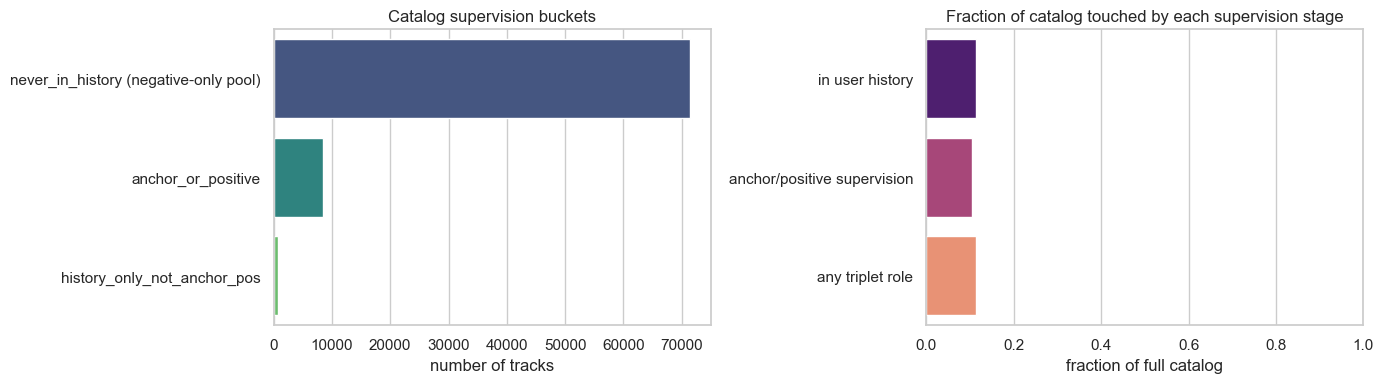

In [52]:
all_tracks = set(range(len(track_df)))
history_tracks = set(tracks_in_history)
anchor_pos_tracks = set(tracks_in_anchor_pos)

coverage_buckets = pd.Series({
    'anchor_or_positive': len(anchor_pos_tracks),
    'history_only_not_anchor_pos': len(history_tracks - anchor_pos_tracks),
    'never_in_history (negative-only pool)': len(all_tracks - history_tracks),
}).sort_values(ascending=False)

display((coverage_buckets.to_frame('tracks')
         .assign(fraction_of_catalog=lambda d: d['tracks'] / len(track_df))))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.barplot(x=coverage_buckets.values, y=coverage_buckets.index, ax=axes[0], palette='viridis')
axes[0].set_title('Catalog supervision buckets')
axes[0].set_xlabel('number of tracks')
axes[0].set_ylabel('')

coverage_plot = pd.DataFrame({
    'role': ['in user history', 'anchor/positive supervision', 'any triplet role'],
    'fraction': [len(history_tracks) / len(track_df), len(anchor_pos_tracks) / len(track_df), len(tracks_in_any_triplet) / len(track_df)],
})
sns.barplot(data=coverage_plot, x='fraction', y='role', ax=axes[1], palette='magma')
axes[1].set_xlim(0, 1)
axes[1].set_title('Fraction of catalog touched by each supervision stage')
axes[1].set_xlabel('fraction of full catalog')
axes[1].set_ylabel('')
plt.tight_layout()


## 4) Triplet integrity audit
The goal here is to verify whether the triplet dataset matches the assumptions of triplet loss.


In [53]:
triplet_integrity = pd.Series({
    'anchor_eq_pos_rate': (triplets_df['anchor_idx'] == triplets_df['pos_idx']).mean(),
    'anchor_eq_neg_rate': (triplets_df['anchor_idx'] == triplets_df['neg_idx']).mean(),
    'pos_eq_neg_rate': (triplets_df['pos_idx'] == triplets_df['neg_idx']).mean(),
})
display(triplet_integrity.to_frame('rate'))

,rate
anchor_eq_pos_rate,0.0000
anchor_eq_neg_rate,0.0000
pos_eq_neg_rate,0.0000


In [54]:
feature_cols = [c for c in track_df.columns if c not in ['artist_norm', 'track_norm']]
feature_matrix = track_df[feature_cols].to_numpy()

anchor_features = feature_matrix[triplets_df['anchor_idx'].to_numpy()]
pos_features = feature_matrix[triplets_df['pos_idx'].to_numpy()]
neg_features = feature_matrix[triplets_df['neg_idx'].to_numpy()]

identical_anchor_pos = np.all(np.isclose(anchor_features, pos_features), axis=1)
identical_anchor_neg = np.all(np.isclose(anchor_features, neg_features), axis=1)

print('Anchor/positive identical-feature rate:', identical_anchor_pos.mean())
print('Anchor/negative identical-feature rate:', identical_anchor_neg.mean())

Anchor/positive identical-feature rate: 0.0
Anchor/negative identical-feature rate: 0.0


### Negative realism
Random negatives can be too easy if they come from tracks no one ever listens to, and they can be false negatives if they come from the same user's history.


In [55]:
seen_tracks = set(history_df['track_idx'])
neg_seen_anywhere = triplets_df['neg_idx'].isin(seen_tracks)

user_track_sets = history_df.groupby('user_id')['track_idx'].apply(set)
same_user_negative = np.fromiter(
    (neg in user_track_sets[user] for user, neg in zip(triplets_df['user_id'], triplets_df['neg_idx'])),
    dtype=bool,
    count=len(triplets_df),
)

negative_quality = pd.Series({
    'negatives_seen_anywhere_rate': neg_seen_anywhere.mean(),
    'negatives_never_seen_rate': (~neg_seen_anywhere).mean(),
    'false_negative_same_user_history_rate': same_user_negative.mean(),
})
display(negative_quality.to_frame('rate'))

,rate
negatives_seen_anywhere_rate,0.9993
negatives_never_seen_rate,0.0007
false_negative_same_user_history_rate,0.0060


<!-- added:negative-viz -->
### Visualize negative difficulty and triplet redundancy
The goal here is to see whether negatives look like plausible alternatives or mostly like easy out-of-support examples, and whether the triplet count overstates supervision diversity.


,rate
negatives_never_seen_anywhere_rate,0.0007
false_negative_same_user_history_rate,0.0060
false_negative_future_eval_rate,0.0060
"repeated_(user,anchor,pos)_rate",0.0000


C:\Users\andyr\AppData\Local\Temp\ipykernel_4180\115830548.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=role_popularity, x='role', y='log1p_play_count', ax=axes[0], palette='Set2', showfliers=False)


Repeated (user, anchor, positive) pairs: 0
Worst repeat count for one (user, anchor, positive) pair: 1


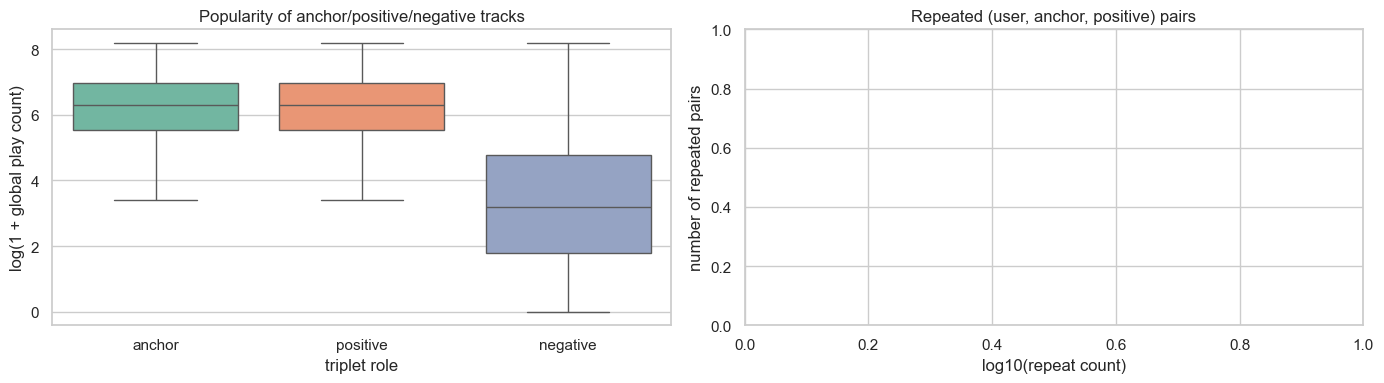

In [56]:
play_counts = history_df['track_idx'].value_counts()
role_popularity = pd.DataFrame({
    'log1p_play_count': np.concatenate([
        np.log1p(triplets_df['anchor_idx'].map(play_counts).fillna(0).to_numpy()),
        np.log1p(triplets_df['pos_idx'].map(play_counts).fillna(0).to_numpy()),
        np.log1p(triplets_df['neg_idx'].map(play_counts).fillna(0).to_numpy()),
    ]),
    'role': (['anchor'] * len(triplets_df)) + (['positive'] * len(triplets_df)) + (['negative'] * len(triplets_df)),
})

triplet_pair_counts = triplets_df.groupby(['user_id', 'anchor_idx', 'pos_idx']).size()
repeated_pairs = triplet_pair_counts[triplet_pair_counts > 1]

future_eval_sets = (
    history_df[history_df['split'] == 'eval']
    .groupby('user_id')['track_idx']
    .apply(set)
)
future_eval_negative = np.fromiter(
    (neg in future_eval_sets.get(user, set()) for user, neg in zip(triplets_df['user_id'], triplets_df['neg_idx'])),
    dtype=bool,
    count=len(triplets_df),
)

negative_summary = pd.Series({
    'negatives_never_seen_anywhere_rate': (~neg_seen_anywhere).mean(),
    'false_negative_same_user_history_rate': same_user_negative.mean(),
    'false_negative_future_eval_rate': future_eval_negative.mean(),
    'repeated_(user,anchor,pos)_rate': triplets_df.set_index(['user_id', 'anchor_idx', 'pos_idx']).index.duplicated().mean(),
})
display(negative_summary.to_frame('rate'))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.boxplot(data=role_popularity, x='role', y='log1p_play_count', ax=axes[0], palette='Set2', showfliers=False)
axes[0].set_title('Popularity of anchor/positive/negative tracks')
axes[0].set_xlabel('triplet role')
axes[0].set_ylabel('log(1 + global play count)')

sns.histplot(np.log10(repeated_pairs.values), bins=40, ax=axes[1], color='steelblue')
axes[1].set_title('Repeated (user, anchor, positive) pairs')
axes[1].set_xlabel('log10(repeat count)')
axes[1].set_ylabel('number of repeated pairs')
plt.tight_layout()

print('Repeated (user, anchor, positive) pairs:', int((triplet_pair_counts > 1).sum()))
print('Worst repeat count for one (user, anchor, positive) pair:', int(triplet_pair_counts.max()))


## 5) User-history structure
This section checks whether repeated listens, sparse users, or poor temporal splits may distort both triplet learning and persona fitting.


In [57]:
user_events = history_df.groupby('user_id').agg(
    total_events=('track_idx', 'size'),
    unique_tracks=('track_idx', 'nunique')
)
user_events['duplicate_ratio'] = 1 - (user_events['unique_tracks'] / user_events['total_events'])
display(user_events.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

,total_events,unique_tracks,duplicate_ratio
count,981.0000,981.0000,981.0000
mean,"1,367.8807",223.2161,0.6538
std,"2,044.4352",201.7986,0.2519
min,1.0000,1.0000,0.0000
10%,59.0000,28.0000,0.2457
25%,221.0000,78.0000,0.5211
50%,708.0000,171.0000,0.7283
75%,"1,621.0000",310.0000,0.8478
90%,"3,433.0000",490.0000,0.9063
95%,"4,886.0000",610.0000,0.9347


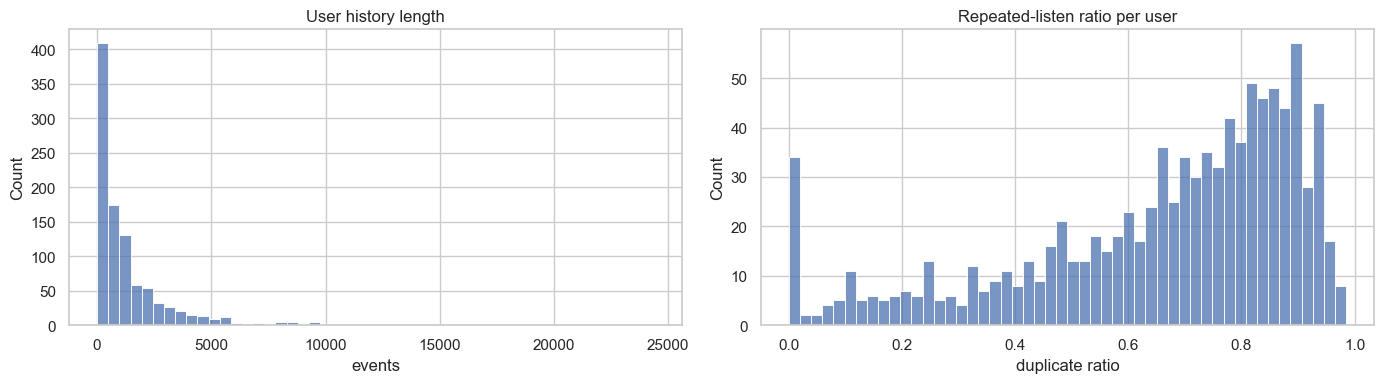

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(user_events['total_events'], bins=50, ax=axes[0])
axes[0].set_title('User history length')
axes[0].set_xlabel('events')

sns.histplot(user_events['duplicate_ratio'], bins=50, ax=axes[1])
axes[1].set_title('Repeated-listen ratio per user')
axes[1].set_xlabel('duplicate ratio')
plt.tight_layout()

In [59]:
split_table = history_df.groupby(['user_id', 'split']).size().unstack(fill_value=0)
train_counts = split_table['train'] if 'train' in split_table else pd.Series(0, index=split_table.index)
eval_counts = split_table['eval'] if 'eval' in split_table else pd.Series(0, index=split_table.index)

split_summary = pd.Series({
    'users_total': len(split_table),
    'users_train_only': ((train_counts > 0) & (eval_counts == 0)).sum(),
    'users_eval_only': ((eval_counts > 0) & (train_counts == 0)).sum(),
    'users_both': ((train_counts > 0) & (eval_counts > 0)).sum(),
})
display(split_summary.to_frame('value'))

,value
users_total,981
users_train_only,0
users_eval_only,8
users_both,973


## 6) Train/validation leakage audit for embedding training
The current training code does a random split over the triplet dataset. This section estimates how much user/track overlap that creates.


In [60]:
rng = np.random.default_rng(42)
perm = rng.permutation(len(triplets_df))
val_size = max(1, int(0.2 * len(triplets_df)))
val_idx = perm[:val_size]
train_idx = perm[val_size:]

train_triplets = triplets_df.iloc[train_idx]
val_triplets = triplets_df.iloc[val_idx]

train_users = set(train_triplets['user_id'])
val_users = set(val_triplets['user_id'])
train_tracks = set(pd.unique(pd.concat([train_triplets['anchor_idx'], train_triplets['pos_idx']], ignore_index=True)))
val_tracks = set(pd.unique(pd.concat([val_triplets['anchor_idx'], val_triplets['pos_idx']], ignore_index=True)))

leakage_df = pd.Series({
    'val_users_also_in_train_rate': len(train_users & val_users) / max(len(val_users), 1),
    'val_anchor_pos_tracks_also_in_train_rate': len(train_tracks & val_tracks) / max(len(val_tracks), 1),
})
display(leakage_df.to_frame('rate'))

,rate
val_users_also_in_train_rate,1.0000
val_anchor_pos_tracks_also_in_train_rate,0.9917


<!-- added:leakage-viz -->
### Visualize how much eval is replay versus discovery
These views complement the random triplet train/val audit by measuring how much of each user's eval set is already in their own training history.


,value
count,981.0000
mean,0.5495
std,0.2584
min,0.0000
10%,0.1667
25%,0.3824
50%,0.5906
75%,0.7429
90%,0.8571
95%,0.9051


Row-level eval overlap rate: 70.51%
Users with any repeated eval track: 93.37%


C:\Users\andyr\AppData\Local\Temp\ipykernel_4180\2348136686.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=leakage_summary_plot, x='rate', y='metric', ax=axes[1], palette='rocket')


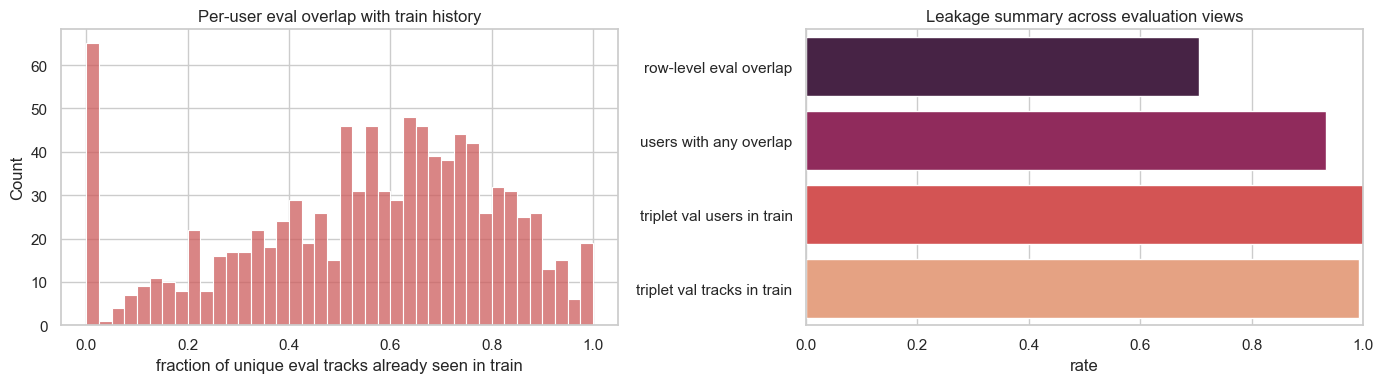

In [61]:
train_history = history_df[history_df['split'] == 'train']
eval_history = history_df[history_df['split'] == 'eval']
train_user_tracks = train_history.groupby('user_id')['track_idx'].apply(set).to_dict()

overlap_rows = []
for user_id, grp in eval_history.groupby('user_id'):
    eval_tracks = set(grp['track_idx'])
    train_tracks_user = train_user_tracks.get(user_id, set())
    overlap = eval_tracks & train_tracks_user
    overlap_rows.append({
        'user_id': user_id,
        'eval_unique_tracks': len(eval_tracks),
        'overlap_unique_tracks': len(overlap),
        'overlap_rate': len(overlap) / max(len(eval_tracks), 1),
    })

overlap_df = pd.DataFrame(overlap_rows)
row_overlap_rate = eval_history.set_index(['user_id', 'track_idx']).index.isin(train_history.set_index(['user_id', 'track_idx']).index).mean()

display(overlap_df['overlap_rate'].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).to_frame('value'))
print(f'Row-level eval overlap rate: {row_overlap_rate:.2%}')
print(f'Users with any repeated eval track: {(overlap_df["overlap_unique_tracks"] > 0).mean():.2%}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(overlap_df['overlap_rate'], bins=40, ax=axes[0], color='indianred')
axes[0].set_title('Per-user eval overlap with train history')
axes[0].set_xlabel('fraction of unique eval tracks already seen in train')

leakage_summary_plot = pd.DataFrame({
    'metric': ['row-level eval overlap', 'users with any overlap', 'triplet val users in train', 'triplet val tracks in train'],
    'rate': [
        row_overlap_rate,
        (overlap_df['overlap_unique_tracks'] > 0).mean(),
        len(train_users & val_users) / max(len(val_users), 1),
        len(train_tracks & val_tracks) / max(len(val_tracks), 1),
    ]
})
sns.barplot(data=leakage_summary_plot, x='rate', y='metric', ax=axes[1], palette='rocket')
axes[1].set_xlim(0, 1)
axes[1].set_title('Leakage summary across evaluation views')
axes[1].set_xlabel('rate')
axes[1].set_ylabel('')
plt.tight_layout()


## 7) Optional raw-event coverage and session health
This section is especially useful if you suspect the join or sessionizer is throwing away too much signal.


,value
matched_event_rate,0.0570
matched_events,"56,986.0000"
raw_events,"1,000,000.0000"
users_with_zero_matched_events,0.0000


,n_events,n_unique_tracks,repeated_track_rate
count,"10,880.0000","10,880.0000","10,880.0000"
mean,3.9260,3.2153,0.0962
std,5.5798,2.4305,0.2061
min,2.0000,1.0000,0.0000
25%,2.0000,2.0000,0.0000
50%,3.0000,2.0000,0.0000
75%,4.0000,4.0000,0.0000
90%,7.0000,6.0000,0.5000
95%,9.0000,8.0000,0.5000
99%,20.0000,13.0000,0.8571


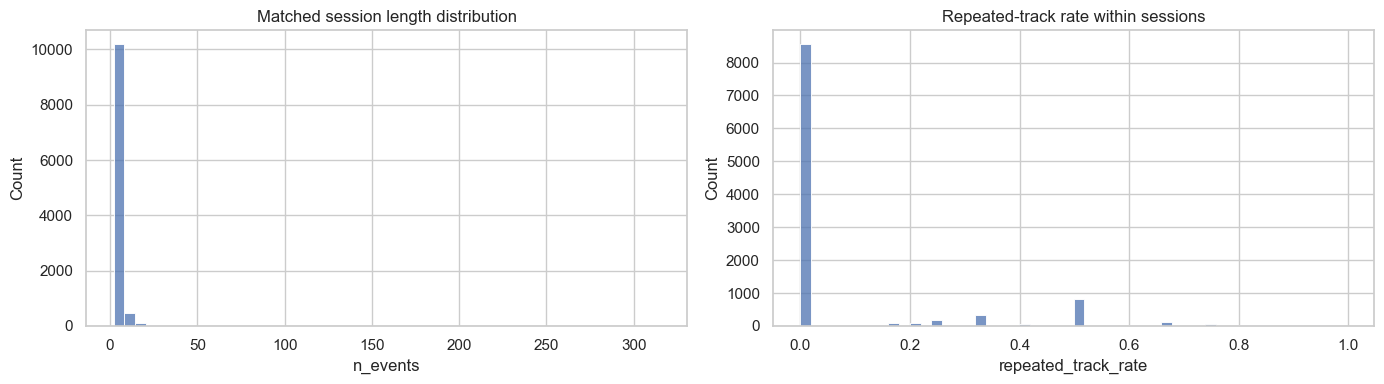

In [62]:
if raw_df is not None:
    lookup = set(zip(track_df['artist_norm'], track_df['track_norm']))
    raw_df['matched'] = list(zip(raw_df['artist_norm'], raw_df['track_norm']))
    raw_df['matched'] = raw_df['matched'].isin(lookup)

    coverage = pd.Series({
        'matched_event_rate': raw_df['matched'].mean(),
        'matched_events': raw_df['matched'].sum(),
        'raw_events': len(raw_df),
        'users_with_zero_matched_events': (raw_df.groupby('user_id')['matched'].mean() == 0).sum(),
    })
    display(coverage.to_frame('value'))

    matched = raw_df[raw_df['matched']].sort_values(['user_id', 'timestamp']).copy()
    matched['delta'] = matched.groupby('user_id')['timestamp'].diff()
    matched['new_session'] = matched['delta'].isna() | (matched['delta'] > pd.Timedelta(minutes=GAP_MINUTES))
    matched['session_id'] = matched.groupby('user_id')['new_session'].cumsum()

    sess = matched.groupby(['user_id', 'session_id']).agg(
        n_events=('track_norm', 'size'),
        n_unique_tracks=('track_norm', 'nunique')
    )
    sess = sess[sess['n_events'] >= MIN_SESSION_LENGTH].copy()
    sess['repeated_track_rate'] = 1 - (sess['n_unique_tracks'] / sess['n_events'])

    display(sess.describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    sns.histplot(sess['n_events'], bins=50, ax=axes[0])
    axes[0].set_title('Matched session length distribution')
    sns.histplot(sess['repeated_track_rate'], bins=50, ax=axes[1])
    axes[1].set_title('Repeated-track rate within sessions')
    plt.tight_layout()
else:
    print('Raw coverage/session analysis skipped.')

<!-- added:join-viz -->
### Visualize raw join coverage by user
If join coverage is poor, this will usually show a long tail of users for whom very little listening behavior survives the exact string match.


,value
count,41.0000
mean,0.0660
std,0.0419
min,0.0103
10%,0.0210
25%,0.0271
50%,0.0636
75%,0.0983
90%,0.1078
95%,0.1415


C:\Users\andyr\AppData\Local\Temp\ipykernel_4180\2618170490.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=hardest_users, x='match_rate', y='user_id', ax=axes[1], palette='crest')


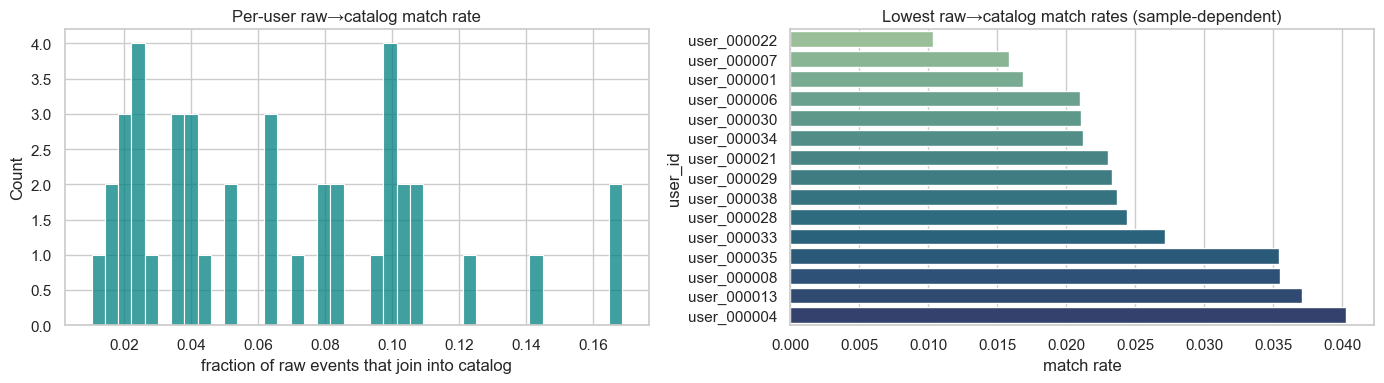

In [63]:
if raw_df is not None:
    per_user_match = raw_df.groupby('user_id')['matched'].agg(['mean', 'size', 'sum']).rename(columns={
        'mean': 'match_rate', 'size': 'raw_events', 'sum': 'matched_events'
    })
    display(per_user_match['match_rate'].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).to_frame('value'))

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    sns.histplot(per_user_match['match_rate'], bins=40, ax=axes[0], color='teal')
    axes[0].set_title('Per-user raw→catalog match rate')
    axes[0].set_xlabel('fraction of raw events that join into catalog')

    hardest_users = per_user_match.sort_values(['match_rate', 'raw_events']).head(15).reset_index()
    sns.barplot(data=hardest_users, x='match_rate', y='user_id', ax=axes[1], palette='crest')
    axes[1].set_title('Lowest raw→catalog match rates (sample-dependent)')
    axes[1].set_xlabel('match rate')
    axes[1].set_ylabel('user_id')
    plt.tight_layout()
else:
    print('Raw coverage visualization skipped.')


## 8) Feature-space sanity checks
Before blaming the model, check whether the engineered inputs themselves are redundant, skewed, or duplicated.


In [64]:
feature_only = track_df[feature_cols].copy()
display(feature_only.describe().T)

dup_feature_groups = feature_only.value_counts()
print('Duplicate feature groups:', int((dup_feature_groups > 1).sum()))
print('Tracks in duplicate feature groups:', int(dup_feature_groups[dup_feature_groups > 1].sum()))

,count,mean,std,min,25%,50%,75%,max
danceability,"80,629.0000",0.5591,0.1778,0.0000,0.4460,0.5730,0.6900,0.9850
energy,"80,629.0000",0.6351,0.2587,0.0000,0.4550,0.6780,0.8570,1.0000
loudness_norm,"80,629.0000",0.8567,0.0885,0.1745,0.8257,0.8788,0.9143,1.0000
acousticness,"80,629.0000",0.3295,0.3398,0.0000,0.0158,0.1900,0.6290,0.9960
instrumentalness,"80,629.0000",0.1855,0.3320,0.0000,0.0000,0.0001,0.1580,1.0000
liveness,"80,629.0000",0.2199,0.1981,0.0000,0.0986,0.1330,0.2830,1.0000
valence,"80,629.0000",0.4631,0.2635,0.0000,0.2410,0.4480,0.6760,0.9950
tempo_norm,"80,629.0000",0.4567,0.1657,0.0000,0.3305,0.4557,0.5561,1.0000
speechiness,"80,629.0000",0.0891,0.1168,0.0000,0.0361,0.0492,0.0872,0.9650
arousal,"80,629.0000",0.5971,0.1665,0.0000,0.5075,0.6330,0.7185,0.9780


Duplicate feature groups: 189
Tracks in duplicate feature groups: 404


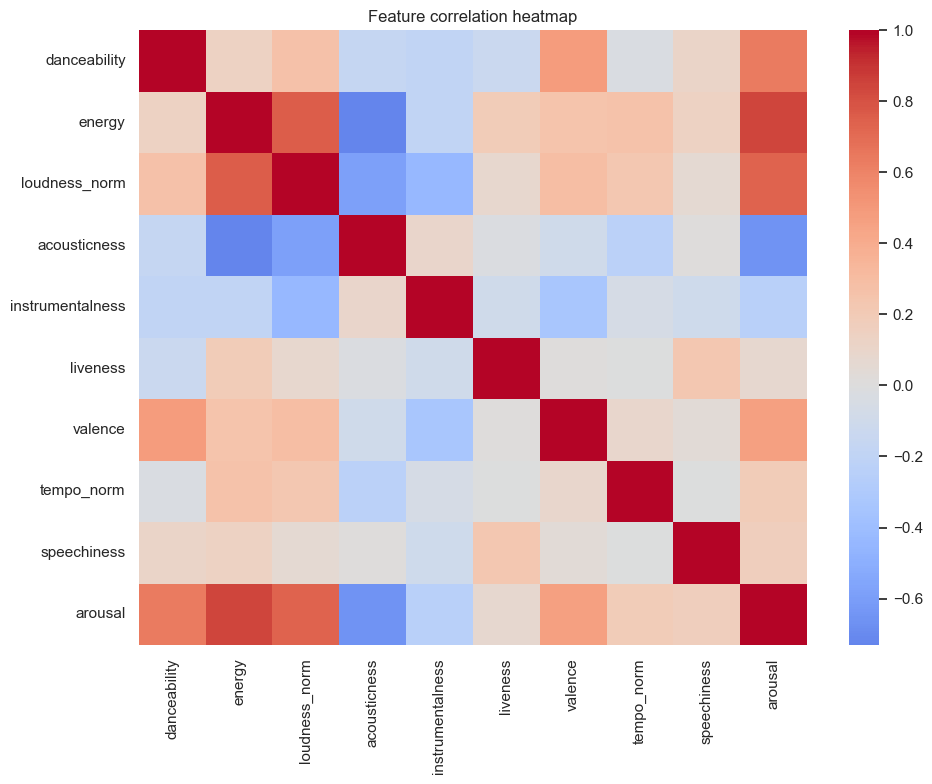

In [65]:
corr = feature_only.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Feature correlation heatmap')
plt.tight_layout()

<!-- added:spotify-dup-viz -->
### Raw Spotify duplicate-key audit
This checks whether the source catalog has multiple rows that collapse to the same normalized `(artist_norm, track_norm)` key, and whether those duplicates disagree on the audio features that survive into training.


Duplicate normalized key groups: 16547
Duplicate groups with conflicting feature vectors: 2403


,artist_norm,track_norm,rows_in_group,feature_variants,tempo_spread,loudness_spread
842,george jones,the race is on,8,7,86.5640,5.9800
830,george jones,he stopped loving her today,6,6,72.7150,9.4320
1785,ray price,crazy arms,6,6,1.1750,3.4500
956,hank williams;drifting cowboys,"hey, good lookin'",6,6,0.2230,3.9840
960,hank williams;drifting cowboys,i saw the light,6,5,102.8540,1.1330
958,hank williams;drifting cowboys,honky tonkin',5,5,2.6810,9.1730
834,george jones,she thinks i still care,5,5,2.0770,6.6860
11,a flock of seagulls,i ran (so far away),5,5,1.0020,7.8400
1318,limahl,never ending story,17,5,0.7160,6.3830
299,bogdan raczynski,myloveilove,4,4,102.2110,6.4220


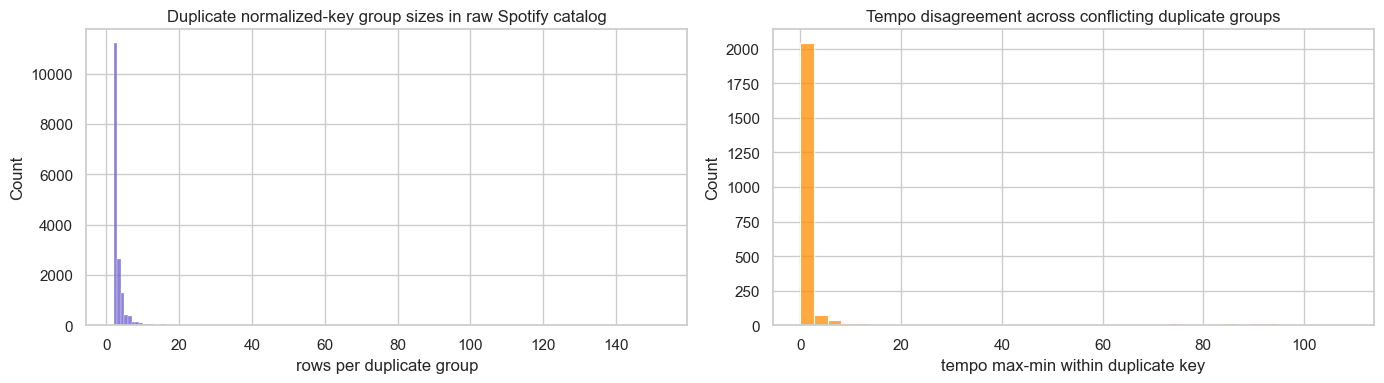

In [66]:
SPOTIFY_CSV_PATH = RAW / 'spotify_tracks.csv'
BASE_FEATURES = [
    'danceability', 'energy', 'loudness', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo'
]

if SPOTIFY_CSV_PATH.exists():
    spotify_raw = pd.read_csv(SPOTIFY_CSV_PATH, low_memory=False)
    spotify_raw['artist_norm'] = spotify_raw['artists'].str.lower().str.strip()
    spotify_raw['track_norm'] = spotify_raw['track_name'].str.lower().str.strip()
    spotify_raw = spotify_raw.dropna(subset=BASE_FEATURES + ['artists', 'track_name'])

    dup_groups = spotify_raw.groupby(['artist_norm', 'track_norm'])
    dup_sizes = dup_groups.size()
    dup_sizes = dup_sizes[dup_sizes > 1]

    conflict_records = []
    for key, grp in dup_groups:
        if len(grp) <= 1:
            continue
        feature_variants = grp[BASE_FEATURES].drop_duplicates()
        if len(feature_variants) > 1:
            tempo_spread = grp['tempo'].max() - grp['tempo'].min()
            loudness_spread = grp['loudness'].max() - grp['loudness'].min()
            conflict_records.append({
                'artist_norm': key[0],
                'track_norm': key[1],
                'rows_in_group': len(grp),
                'feature_variants': len(feature_variants),
                'tempo_spread': tempo_spread,
                'loudness_spread': loudness_spread,
            })

    conflict_df = pd.DataFrame(conflict_records).sort_values(['feature_variants', 'tempo_spread'], ascending=False)
    print('Duplicate normalized key groups:', len(dup_sizes))
    print('Duplicate groups with conflicting feature vectors:', len(conflict_df))
    display(conflict_df.head(15))

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    sns.histplot(dup_sizes, bins=range(2, int(dup_sizes.max()) + 2), ax=axes[0], color='slateblue')
    axes[0].set_title('Duplicate normalized-key group sizes in raw Spotify catalog')
    axes[0].set_xlabel('rows per duplicate group')

    if not conflict_df.empty:
        sns.histplot(conflict_df['tempo_spread'], bins=40, ax=axes[1], color='darkorange')
        axes[1].set_title('Tempo disagreement across conflicting duplicate groups')
        axes[1].set_xlabel('tempo max-min within duplicate key')
    else:
        axes[1].text(0.5, 0.5, 'No conflicting duplicate groups found', ha='center', va='center')
        axes[1].set_axis_off()
    plt.tight_layout()
else:
    print('Raw Spotify duplicate audit skipped because spotify_tracks.csv was not found.')


## 9) Architecture-alignment checklist
Use this table as the final decision layer before retraining.


In [67]:
decision_table = pd.DataFrame([
    {
        'question': 'Are positives distinct from anchors?',
        'metric': 'anchor_eq_pos_rate',
        'value': (triplets_df['anchor_idx'] == triplets_df['pos_idx']).mean(),
        'good_if': '< 1%',
        'risk_if_high': 'Triplet loss gets weak or degenerate supervision'
    },
    {
        'question': 'Are negatives realistic?',
        'metric': 'negatives_never_seen_rate',
        'value': (~triplets_df['neg_idx'].isin(seen_tracks)).mean(),
        'good_if': 'moderate, not extreme',
        'risk_if_high': 'Negatives become too easy / out-of-distribution'
    },
    {
        'question': 'Is embedding validation clean?',
        'metric': 'val_users_also_in_train_rate',
        'value': len(train_users & val_users) / max(len(val_users), 1),
        'good_if': 'low',
        'risk_if_high': 'Validation overestimates generalization'
    },
    {
        'question': 'How much of the catalog gets positive supervision?',
        'metric': 'tracks_in_anchor_or_positive_fraction',
        'value': len(tracks_in_anchor_pos) / len(track_df),
        'good_if': 'higher is better',
        'risk_if_low': 'Most of catalog learned mostly as negatives'
    },
    {
        'question': 'Do repeated listens dominate user modeling?',
        'metric': 'median_duplicate_ratio_per_user',
        'value': user_events['duplicate_ratio'].median(),
        'good_if': 'depends on product goal',
        'risk_if_high': 'Personas may model replay loops more than taste breadth'
    },
])
display(decision_table)

,question,metric,value,good_if,risk_if_high,risk_if_low
0,Are positives distinct from anchors?,anchor_eq_pos_rate,0.0000,< 1%,Triplet loss gets weak or degenerate supervision,NaN
1,Are negatives realistic?,negatives_never_seen_rate,0.0007,"moderate, not extreme",Negatives become too easy / out-of-distribution,NaN
2,Is embedding validation clean?,val_users_also_in_train_rate,1.0000,low,Validation overestimates generalization,NaN
3,How much of the catalog gets positive supervis...,tracks_in_anchor_or_positive_fraction,0.1050,higher is better,NaN,Most of catalog learned mostly as negatives
4,Do repeated listens dominate user modeling?,median_duplicate_ratio_per_user,0.7283,depends on product goal,Personas may model replay loops more than tast...,NaN


## 10) What to do with the results
If the metrics are bad, the likely next fixes are:

1. **Triplet builder**: exclude identical `anchor_idx == pos_idx` pairs
2. **Negative sampling**: sample from listened tracks or hard-neighbor tracks, not uniformly from the whole catalog
3. **Embedding validation**: validate on temporally held-out triplets, not random rows from the same triplet pool
4. **Persona/emotion scoring**: stop assuming a latent embedding dimension still corresponds to raw valence
5. **Replay handling**: decide whether repeated listens should be downweighted, capped, or preserved intentionally


## 12) Train/Eval Distribution Shift Diagnosis
Section 6 checked for leakage (user/track overlap) and found 100% user overlap — expected for a temporal split. But **leakage ≠ distribution shift**. This section tests whether the *distributions* of features, artists, and session structures change between the train and eval periods, which would explain a generalization gap.


C:\Users\andyr\AppData\Local\Temp\ipykernel_4180\1554647020.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=shift_df, x='feature', y='mean_diff', ax=ax, palette='Set2', showfliers=False)


Fraction of users with significant KS shift (p<0.05) per feature:


,frac_users_significant_shift
danceability,0.6119
energy,0.6172
loudness_norm,0.6066
acousticness,0.6416
instrumentalness,0.6352
liveness,0.5228
valence,0.5695
tempo_norm,0.5589
speechiness,0.5578
arousal,0.6267


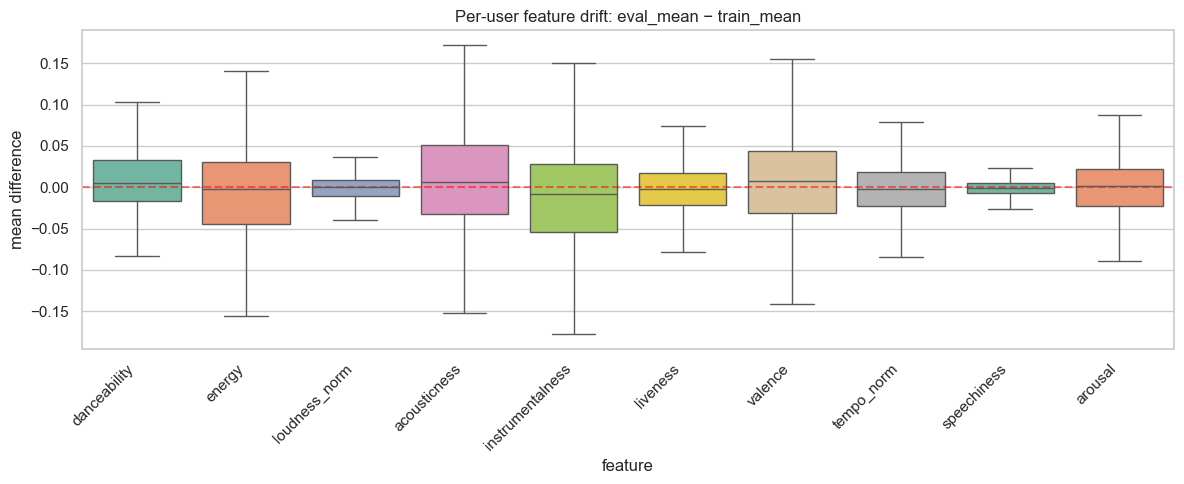

In [ ]:
from scipy import stats as sp_stats

train_history = history_df[history_df['split'] == 'train']
eval_history = history_df[history_df['split'] == 'eval']

feature_cols_clean = [c for c in track_df.columns if c not in ['artist_norm', 'track_norm']]
feat_matrix = track_df[feature_cols_clean].to_numpy()

# Compute per-user mean feature vectors in train vs eval
shift_records = []
ks_results = {f: [] for f in feature_cols_clean}

for user_id in train_history['user_id'].unique():
    tr = train_history[train_history['user_id'] == user_id]['track_idx'].to_numpy()
    ev = eval_history[eval_history['user_id'] == user_id]['track_idx'].to_numpy()
    tr = tr[tr < len(feat_matrix)]
    ev = ev[ev < len(feat_matrix)]
    if len(tr) < 5 or len(ev) < 3:
        continue
    tr_feats = feat_matrix[tr]
    ev_feats = feat_matrix[ev]
    for i, f in enumerate(feature_cols_clean):
        diff = ev_feats[:, i].mean() - tr_feats[:, i].mean()
        shift_records.append({'user_id': user_id, 'feature': f, 'mean_diff': diff})
        stat, pval = sp_stats.ks_2samp(tr_feats[:, i], ev_feats[:, i])
        ks_results[f].append(pval < 0.05)

shift_df = pd.DataFrame(shift_records)

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=shift_df, x='feature', y='mean_diff', ax=ax, palette='Set2', showfliers=False)
ax.axhline(0, color='red', ls='--', alpha=0.5)
ax.set_title('Per-user feature drift: eval_mean − train_mean')
ax.set_ylabel('mean difference')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

ks_summary = pd.Series({f: np.mean(v) for f, v in ks_results.items()}).to_frame('frac_users_significant_shift')
print('Fraction of users with significant KS shift (p<0.05) per feature:')
display(ks_summary)


Median artist overlap: 67.82%
Users with <50% artist overlap: 22.8%


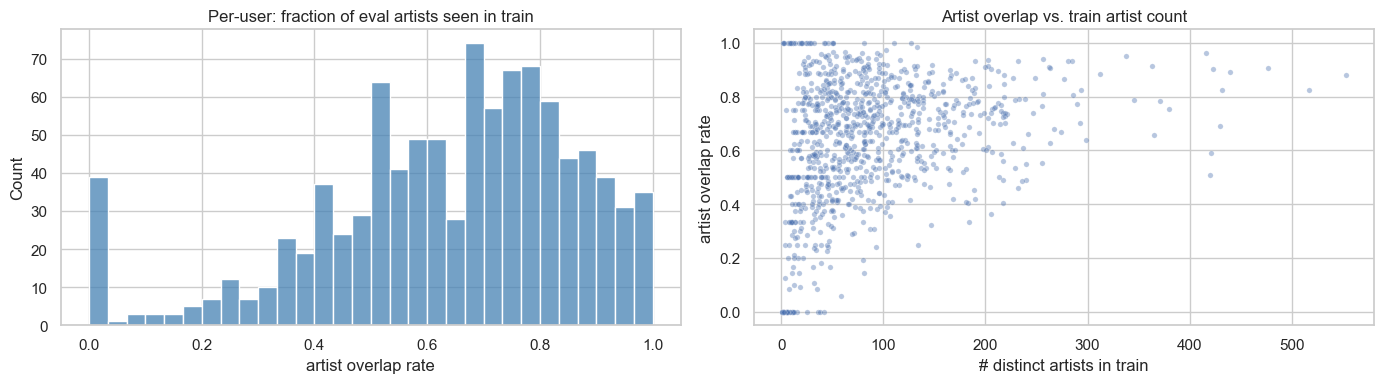

In [ ]:
train_user_artists = train_history.merge(
    track_df[['artist_norm']].reset_index().rename(columns={'index': 'track_idx'}),
    on='track_idx', how='left'
).groupby('user_id')['artist_norm'].apply(set)

eval_user_artists = eval_history.merge(
    track_df[['artist_norm']].reset_index().rename(columns={'index': 'track_idx'}),
    on='track_idx', how='left'
).groupby('user_id')['artist_norm'].apply(set)

artist_overlap_rates = []
for uid in eval_user_artists.index:
    if uid in train_user_artists.index:
        ev_arts = eval_user_artists[uid]
        tr_arts = train_user_artists[uid]
        if len(ev_arts) > 0:
            artist_overlap_rates.append({'user_id': uid, 'overlap': len(ev_arts & tr_arts) / len(ev_arts),
                                        'train_artists': len(tr_arts)})

ao_df = pd.DataFrame(artist_overlap_rates)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(ao_df['overlap'], bins=30, ax=axes[0], color='steelblue')
axes[0].set_title('Per-user: fraction of eval artists seen in train')
axes[0].set_xlabel('artist overlap rate')
sns.scatterplot(data=ao_df, x='train_artists', y='overlap', ax=axes[1], alpha=0.4, s=15)
axes[1].set_title('Artist overlap vs. train artist count')
axes[1].set_xlabel('# distinct artists in train')
axes[1].set_ylabel('artist overlap rate')
plt.tight_layout()

print(f'Median artist overlap: {ao_df["overlap"].median():.2%}')
print(f'Users with <50% artist overlap: {(ao_df["overlap"] < 0.5).mean():.1%}')


Median centroid drift: 0.0032
Users with centroid drift > 0.01: 19.6%
Users with centroid drift > 0.05: 0.9%


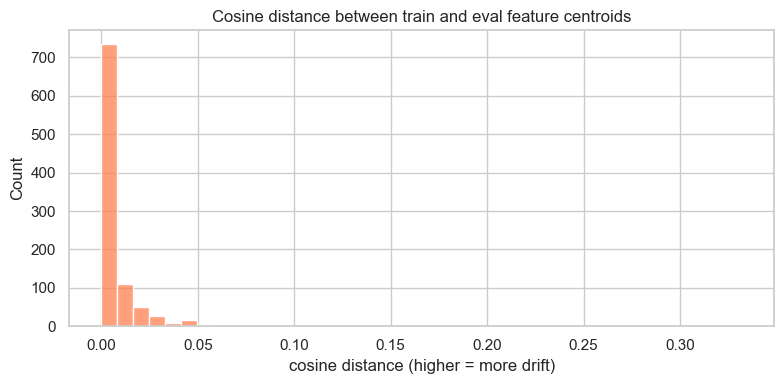

In [ ]:
from sklearn.metrics.pairwise import cosine_distances

centroid_records = []
for user_id in train_history['user_id'].unique():
    tr = train_history[train_history['user_id'] == user_id]['track_idx'].to_numpy()
    ev = eval_history[eval_history['user_id'] == user_id]['track_idx'].to_numpy()
    tr = tr[tr < len(feat_matrix)]; ev = ev[ev < len(feat_matrix)]
    if len(tr) < 3 or len(ev) < 2:
        continue
    tr_cent = feat_matrix[tr].mean(axis=0).reshape(1, -1)
    ev_cent = feat_matrix[ev].mean(axis=0).reshape(1, -1)
    cdist = cosine_distances(tr_cent, ev_cent)[0, 0]
    centroid_records.append({'user_id': user_id, 'centroid_distance': cdist})

cent_df = pd.DataFrame(centroid_records)
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(cent_df['centroid_distance'], bins=40, ax=ax, color='coral')
ax.set_title('Cosine distance between train and eval feature centroids')
ax.set_xlabel('cosine distance (higher = more drift)')
plt.tight_layout()

print(f'Median centroid drift: {cent_df["centroid_distance"].median():.4f}')
print(f'Users with centroid drift > 0.01: {(cent_df["centroid_distance"] > 0.01).mean():.1%}')
print(f'Users with centroid drift > 0.05: {(cent_df["centroid_distance"] > 0.05).mean():.1%}')


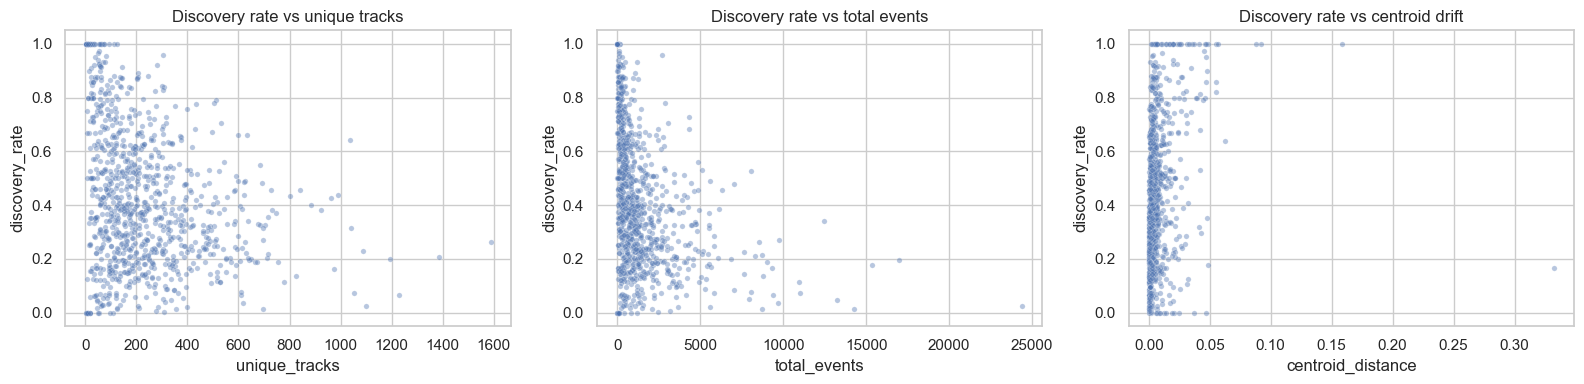

In [ ]:
has_disc = 'is_discovery' in history_df.columns
if has_disc:
    disc_rates = eval_history.groupby('user_id')['is_discovery'].mean().rename('discovery_rate')
    user_chars = user_events[['total_events', 'unique_tracks']].copy()
    user_chars = user_chars.join(disc_rates, how='inner')
    if not cent_df.empty:
        user_chars = user_chars.join(cent_df.set_index('user_id')['centroid_distance'], how='left')

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    sns.scatterplot(data=user_chars, x='unique_tracks', y='discovery_rate', ax=axes[0], alpha=0.4, s=15)
    axes[0].set_title('Discovery rate vs unique tracks')
    sns.scatterplot(data=user_chars, x='total_events', y='discovery_rate', ax=axes[1], alpha=0.4, s=15)
    axes[1].set_title('Discovery rate vs total events')
    if 'centroid_distance' in user_chars.columns:
        sns.scatterplot(data=user_chars, x='centroid_distance', y='discovery_rate', ax=axes[2], alpha=0.4, s=15)
        axes[2].set_title('Discovery rate vs centroid drift')
    else:
        axes[2].set_visible(False)
    plt.tight_layout()
else:
    print('No is_discovery column — skipping discovery rate analysis.')


## 13) Feature Space — User-Listened vs. Full Catalog
Section 8 analyzed feature distributions for the *full* catalog. But are the tracks users actually listen to drawn from a **different region** of feature space? If so, negatives sampled from the full catalog are "easy" out-of-distribution examples, and the triplet loss may not learn nuanced similarity.


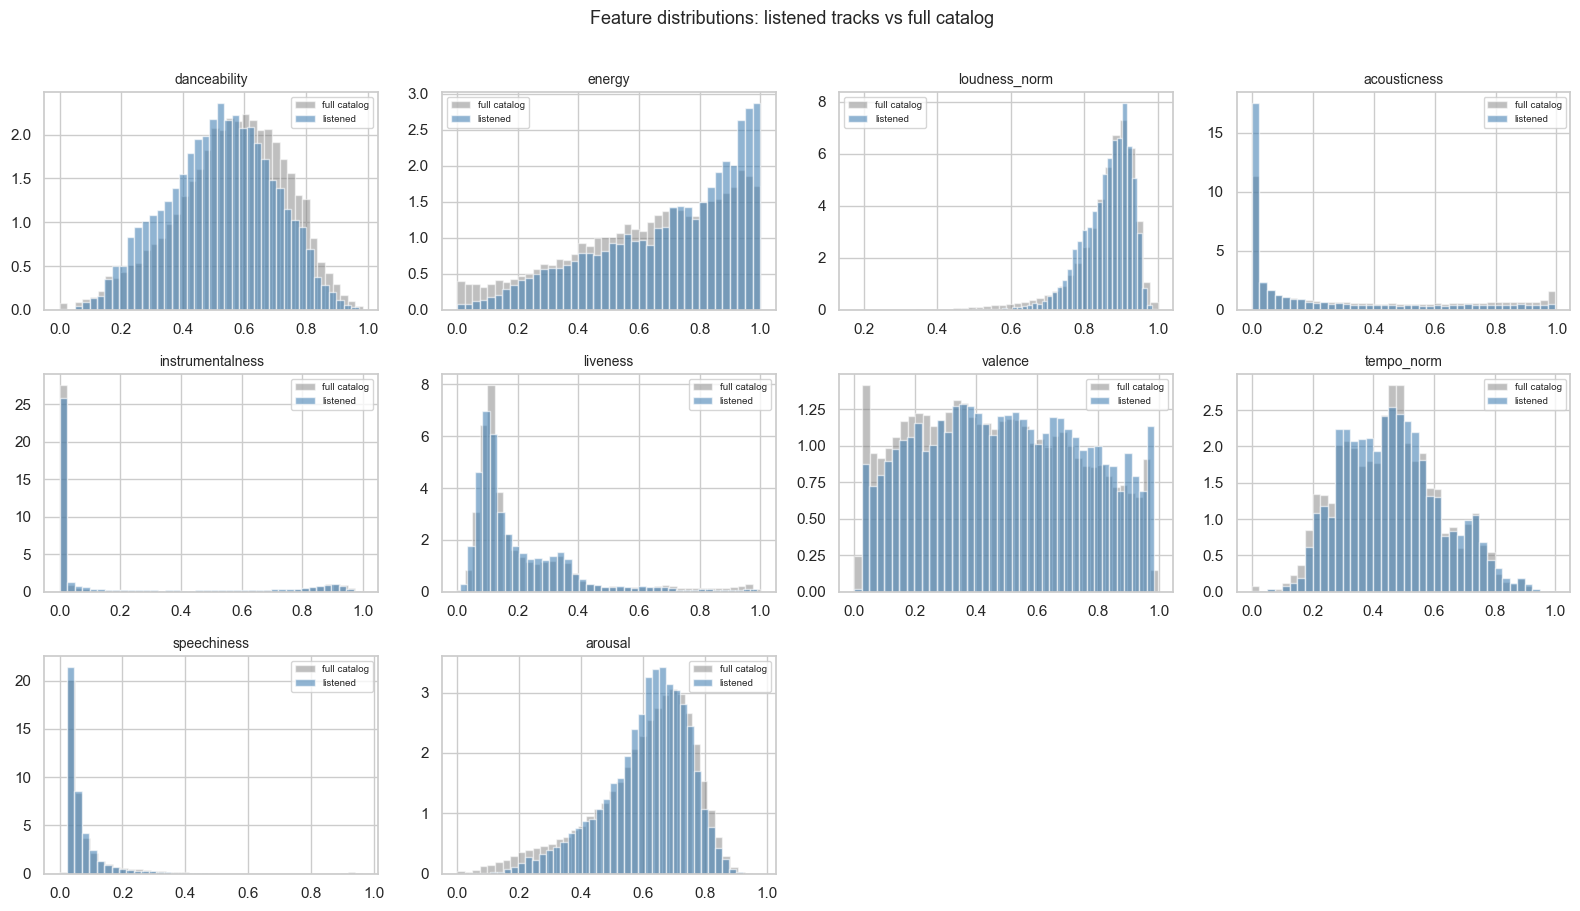

In [ ]:
listened_indices = pd.unique(history_df['track_idx'])
listened_indices = listened_indices[listened_indices < len(track_df)]
listened_mask = np.zeros(len(track_df), dtype=bool)
listened_mask[listened_indices] = True

n_feats = len(feature_cols_clean)
n_cols = 4
n_rows = (n_feats + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3 * n_rows))
axes_flat = axes.flatten()

for i, f in enumerate(feature_cols_clean):
    ax = axes_flat[i]
    ax.hist(track_df[f].values, bins=40, alpha=0.5, label='full catalog', density=True, color='gray')
    ax.hist(track_df[f].values[listened_mask], bins=40, alpha=0.6, label='listened', density=True, color='steelblue')
    ax.set_title(f, fontsize=10)
    ax.legend(fontsize=7)
for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)
fig.suptitle('Feature distributions: listened tracks vs full catalog', fontsize=13, y=1.01)
plt.tight_layout()


C:\Users\andyr\AppData\Local\Temp\ipykernel_4180\2712783101.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=kl_df['KL_divergence'].values, y=kl_df.index, ax=ax, palette='magma')


,KL_divergence
acousticness,0.0709
energy,0.0413
danceability,0.0359
loudness_norm,0.0344
arousal,0.0289
speechiness,0.0233
instrumentalness,0.0196
tempo_norm,0.0172
liveness,0.0168
valence,0.0151


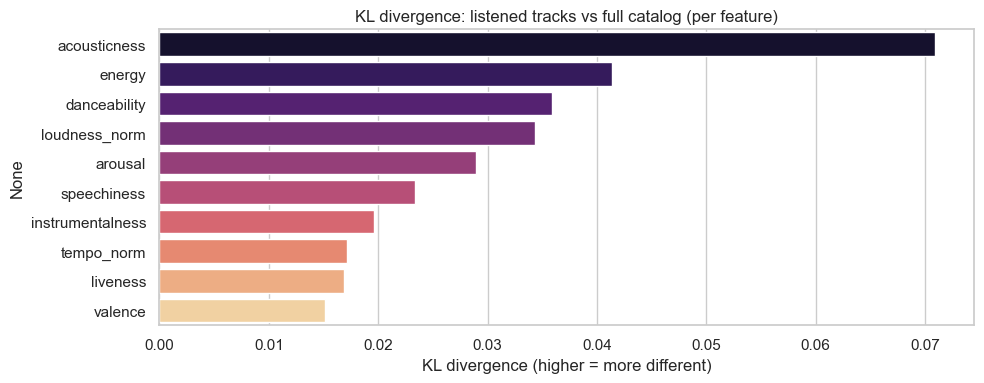

In [ ]:
from scipy.special import rel_entr

kl_vals = {}
for f in feature_cols_clean:
    full_hist, edges = np.histogram(track_df[f].values, bins=50, density=True)
    list_hist, _ = np.histogram(track_df[f].values[listened_mask], bins=edges, density=True)
    # Add small epsilon to avoid log(0)
    eps = 1e-10
    full_hist = full_hist + eps; list_hist = list_hist + eps
    full_hist /= full_hist.sum(); list_hist /= list_hist.sum()
    kl_vals[f] = rel_entr(list_hist, full_hist).sum()

kl_df = pd.Series(kl_vals).sort_values(ascending=False).to_frame('KL_divergence')
fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(x=kl_df['KL_divergence'].values, y=kl_df.index, ax=ax, palette='magma')
ax.set_title('KL divergence: listened tracks vs full catalog (per feature)')
ax.set_xlabel('KL divergence (higher = more different)')
plt.tight_layout()
display(kl_df)


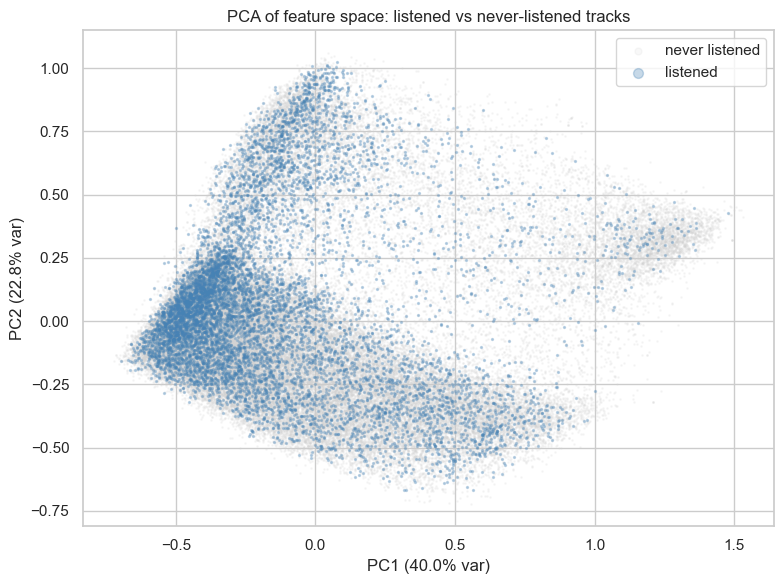

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
all_feats = track_df[feature_cols_clean].to_numpy()
coords = pca.fit_transform(all_feats)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(coords[~listened_mask, 0], coords[~listened_mask, 1],
           s=1, alpha=0.15, label='never listened', color='lightgray')
ax.scatter(coords[listened_mask, 0], coords[listened_mask, 1],
           s=2, alpha=0.3, label='listened', color='steelblue')
ax.set_title('PCA of feature space: listened vs never-listened tracks')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)')
ax.legend(markerscale=5)
plt.tight_layout()


## 14) User Diversity Profiling
Section 5 showed user-history length and repeat-listen ratios. This section goes deeper: **how concentrated vs. diverse is each user's taste?** We compute artist-level concentration metrics and classify users into niche/diverse/mainstream types — directly feeding Experiment 2 (persona validation).


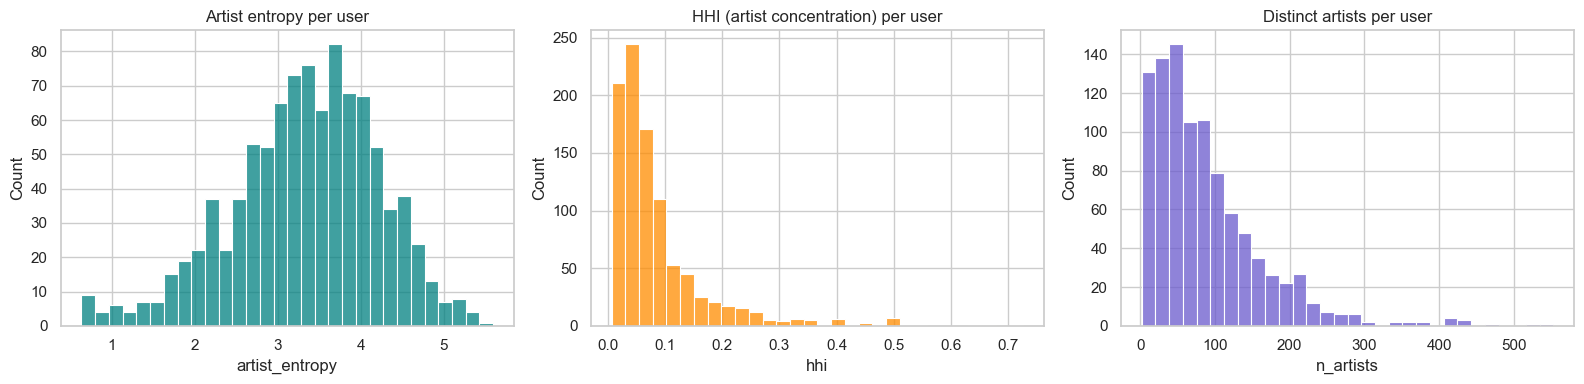

In [ ]:
from scipy.stats import entropy as sp_entropy

train_hist = history_df[history_df['split'] == 'train'].copy()
train_hist = train_hist[train_hist['track_idx'] < len(track_df)]
train_hist = train_hist.merge(
    track_df[['artist_norm']].reset_index().rename(columns={'index': 'track_idx'}),
    on='track_idx', how='left'
)

diversity_records = []
for user_id, grp in train_hist.groupby('user_id'):
    art_counts = grp['artist_norm'].value_counts()
    n_artists = len(art_counts)
    if n_artists < 2:
        continue
    proportions = art_counts.values / art_counts.values.sum()
    hhi = (proportions ** 2).sum()
    ent = sp_entropy(proportions)
    diversity_records.append({
        'user_id': user_id, 'n_artists': n_artists,
        'hhi': hhi, 'artist_entropy': ent,
        'total_plays': len(grp), 'unique_tracks': grp['track_idx'].nunique()
    })

div_df = pd.DataFrame(diversity_records)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(div_df['artist_entropy'], bins=30, ax=axes[0], color='teal')
axes[0].set_title('Artist entropy per user')
sns.histplot(div_df['hhi'], bins=30, ax=axes[1], color='darkorange')
axes[1].set_title('HHI (artist concentration) per user')
sns.histplot(div_df['n_artists'], bins=30, ax=axes[2], color='slateblue')
axes[2].set_title('Distinct artists per user')
plt.tight_layout()


,count,median_artists,median_tracks,median_plays,median_entropy,median_hhi
user_type,,,,,,
diverse,330,139.5000,302.5000,"1,073.0000",4.1520,0.0272
mainstream,319,65.0000,142.0000,604.0000,3.3923,0.0569
niche,320,25.0000,50.5000,175.5000,2.5022,0.1354


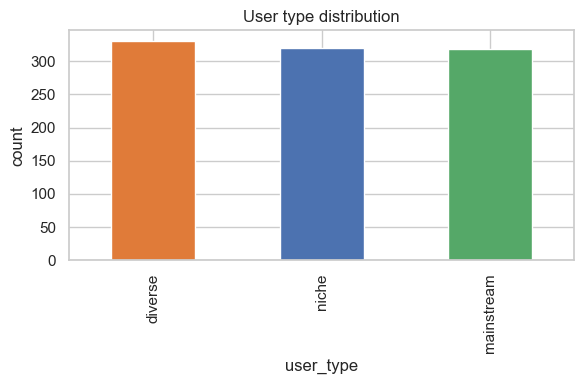

In [ ]:
if len(div_df) > 0:
    thresholds = div_df['artist_entropy'].quantile([0.33, 0.66])
    def classify_user(ent):
        if ent <= thresholds.iloc[0]:
            return 'niche'
        elif ent >= thresholds.iloc[1]:
            return 'diverse'
        return 'mainstream'

    div_df['user_type'] = div_df['artist_entropy'].apply(classify_user)
    type_summary = div_df.groupby('user_type').agg(
        count=('user_id', 'size'),
        median_artists=('n_artists', 'median'),
        median_tracks=('unique_tracks', 'median'),
        median_plays=('total_plays', 'median'),
        median_entropy=('artist_entropy', 'median'),
        median_hhi=('hhi', 'median'),
    )
    display(type_summary)

    fig, ax = plt.subplots(figsize=(6, 4))
    div_df['user_type'].value_counts().plot.bar(ax=ax, color=['#E07B39', '#4C72B0', '#55A868'])
    ax.set_title('User type distribution')
    ax.set_ylabel('count')
    plt.tight_layout()


## 15) Candidate Discovery Metrics
The current evaluation uses `Discovery@K` (fraction of recs in held-out eval set) and `NDCG@K`. These are coarse — they only measure whether a rec appears in the eval set, ignoring **how novel** the recommendation truly is.

This section defines 7 candidate metrics and computes them on a **random baseline** and a **popularity baseline** to assess their discriminative power.

| Metric | Captures |
|--------|----------|
| Artist Novelty Rate | Are we introducing new *artists*? |
| Feature Space Exploration | How far out of the user's comfort zone? |
| Intra-list Diversity | Are recs diverse or clustered? |
| Popularity Percentile | Anti-popularity principle |
| Discovery Reach | Recall over discovery set |


In [ ]:
from sklearn.metrics.pairwise import cosine_distances as cos_dist

def artist_novelty_rate(rec_indices, user_train_indices, all_artists):
    """Fraction of recs from artists user has never listened to."""
    train_artists = set(all_artists[i] for i in user_train_indices if i < len(all_artists))
    novel = sum(1 for i in rec_indices if all_artists[i] not in train_artists)
    return novel / max(len(rec_indices), 1)

def feature_exploration(rec_indices, user_train_indices, feat_mat):
    """Mean cosine distance from each rec to nearest track in user's train history."""
    if len(user_train_indices) == 0 or len(rec_indices) == 0:
        return 0.0
    rec_feats = feat_mat[rec_indices]
    train_feats = feat_mat[user_train_indices]
    dists = cos_dist(rec_feats, train_feats)
    return float(dists.min(axis=1).mean())

def intralist_diversity(rec_indices, feat_mat):
    """Mean pairwise cosine distance among recs."""
    if len(rec_indices) < 2:
        return 0.0
    rec_feats = feat_mat[rec_indices]
    dists = cos_dist(rec_feats, rec_feats)
    n = len(rec_indices)
    return float(dists.sum() / (n * (n - 1))) if n > 1 else 0.0

def popularity_percentile(rec_indices, play_counts):
    """Mean popularity percentile of recs (0=obscure, 1=mainstream)."""
    ranks = play_counts.rank(pct=True)
    vals = [ranks.get(i, 0.0) for i in rec_indices]
    return np.mean(vals) if vals else 0.0

def discovery_reach(rec_indices, discovery_set):
    """Fraction of user's eval discoveries covered by recs (recall)."""
    if not discovery_set:
        return 0.0
    hits = sum(1 for i in rec_indices if i in discovery_set)
    return hits / len(discovery_set)

print('Metric functions defined.')


Metric functions defined.


In [ ]:
all_artists = track_df['artist_norm'].to_numpy()
play_counts = history_df['track_idx'].value_counts()
feat_mat_full = track_df[feature_cols_clean].to_numpy(dtype=np.float32)

has_disc_col = 'is_discovery' in history_df.columns
K = 20
rng = np.random.default_rng(42)

baseline_records = []
sample_users = div_df['user_id'].values[:min(100, len(div_df))]

pop_sorted = play_counts.sort_values(ascending=False).index.to_numpy()
pop_recs_pool = pop_sorted[pop_sorted < len(track_df)][:200]

for uid in sample_users:
    tr_rows = train_hist[train_hist['user_id'] == uid]
    tr_indices = tr_rows['track_idx'].unique()
    tr_indices = tr_indices[tr_indices < len(feat_mat_full)]
    if len(tr_indices) < 5:
        continue

    ev_rows = history_df[(history_df['user_id'] == uid) & (history_df['split'] == 'eval')]
    if has_disc_col:
        disc_set = set(ev_rows[ev_rows['is_discovery']]['track_idx'].to_numpy())
    else:
        disc_set = set(ev_rows['track_idx'].to_numpy())

    # Random recs
    rand_recs = rng.choice(len(track_df), size=K, replace=False)
    # Popularity recs
    pop_recs = pop_recs_pool[:K]

    for label, recs in [('random', rand_recs), ('popularity', pop_recs)]:
        baseline_records.append({
            'user_id': uid, 'baseline': label,
            'artist_novelty': artist_novelty_rate(recs, tr_indices, all_artists),
            'feature_exploration': feature_exploration(recs, tr_indices, feat_mat_full),
            'intralist_diversity': intralist_diversity(recs, feat_mat_full),
            'popularity_pctile': popularity_percentile(recs, play_counts),
            'discovery_reach': discovery_reach(recs, disc_set),
        })

base_df = pd.DataFrame(baseline_records)
print(f'Computed metrics for {len(sample_users)} users × 2 baselines')


Computed metrics for 100 users × 2 baselines


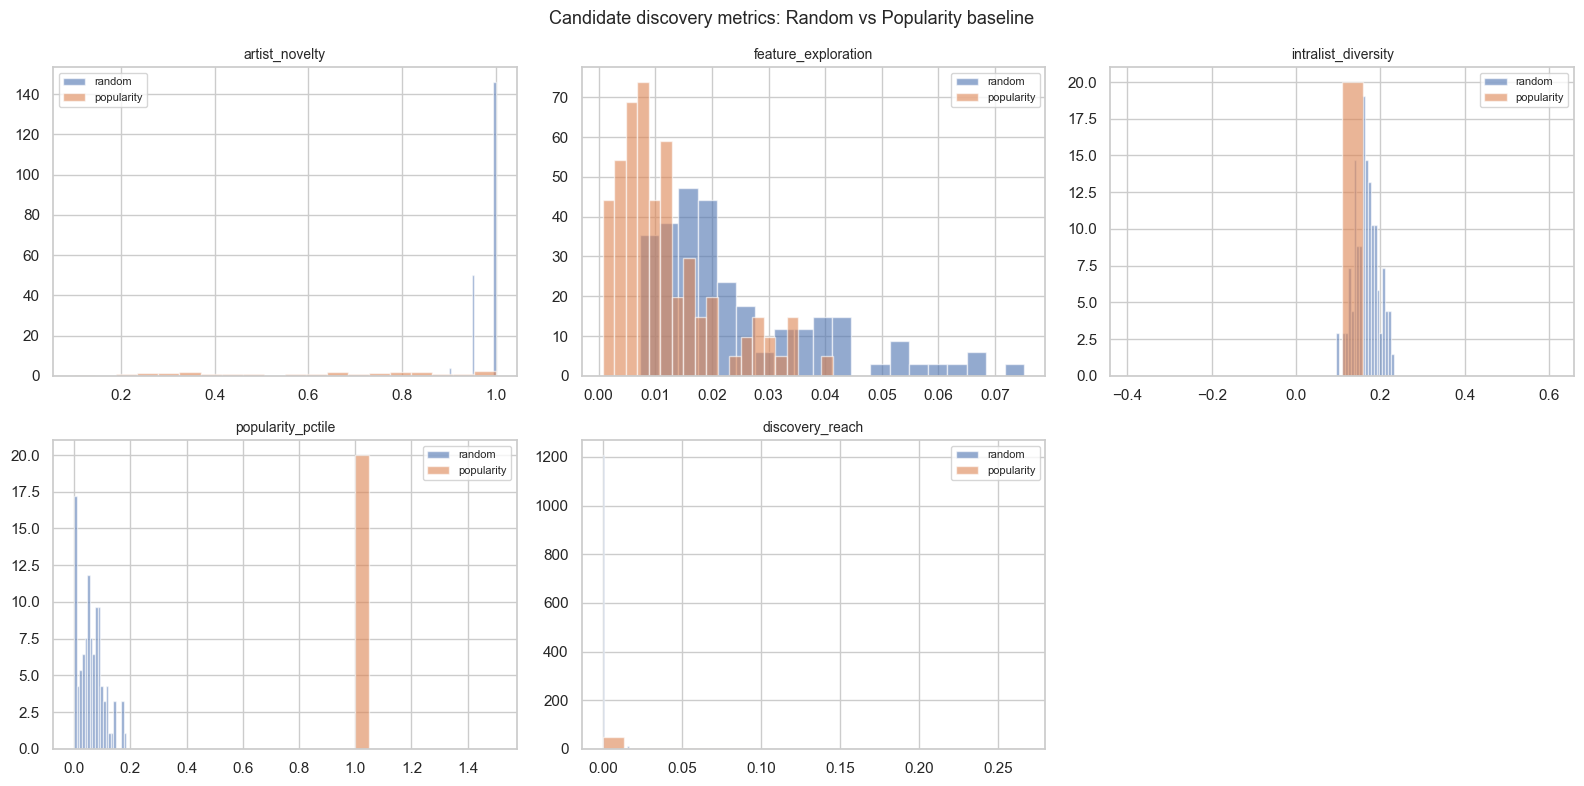

In [ ]:
metric_cols = ['artist_novelty', 'feature_exploration', 'intralist_diversity',
               'popularity_pctile', 'discovery_reach']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes_flat = axes.flatten()
for i, col in enumerate(metric_cols):
    ax = axes_flat[i]
    for label, color in [('random', '#4C72B0'), ('popularity', '#DD8452')]:
        vals = base_df[base_df['baseline'] == label][col]
        ax.hist(vals, bins=20, alpha=0.6, label=label, color=color, density=True)
    ax.set_title(col, fontsize=10)
    ax.legend(fontsize=8)
axes_flat[-1].set_visible(False)
fig.suptitle('Candidate discovery metrics: Random vs Popularity baseline', fontsize=13)
plt.tight_layout()


Highly correlated pairs (|r| > 0.6):


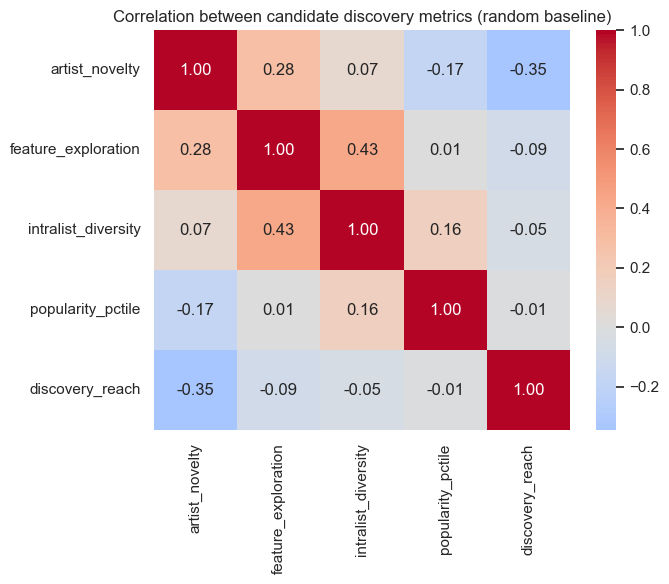

In [ ]:
metric_means = base_df[base_df['baseline'] == 'random'].groupby('user_id')[metric_cols].mean()
corr = metric_means.corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation between candidate discovery metrics (random baseline)')
plt.tight_layout()

print('Highly correlated pairs (|r| > 0.6):')
for i in range(len(corr)):
    for j in range(i+1, len(corr)):
        if abs(corr.iloc[i, j]) > 0.6:
            print(f'  {corr.index[i]} ↔ {corr.columns[j]}: {corr.iloc[i, j]:.2f}')


## 16) Composite Discovery Score Exploration
Can we combine the most orthogonal candidate metrics into a single **composite discovery score** that captures more than `Discovery@K` alone?


Explained variance per component: ['33.08%', '25.47%', '19.37%', '12.16%', '9.93%']


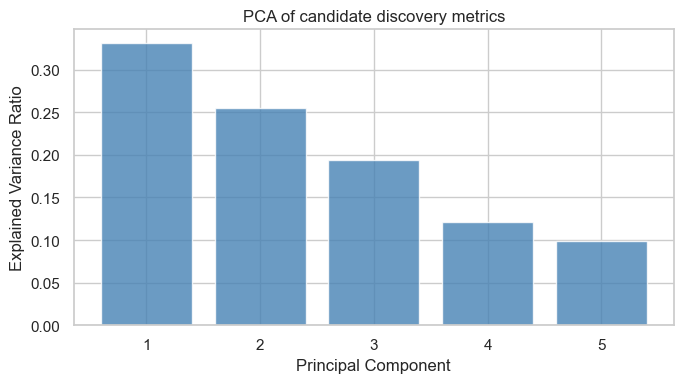

In [ ]:
from sklearn.preprocessing import StandardScaler

if len(metric_means) > 5:
    scaler = StandardScaler()
    scaled = scaler.fit_transform(metric_means.dropna())
    pca_metrics = PCA(n_components=min(len(metric_cols), len(metric_means)))
    pca_metrics.fit(scaled)

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(range(1, len(pca_metrics.explained_variance_ratio_) + 1),
           pca_metrics.explained_variance_ratio_, color='steelblue', alpha=0.8)
    ax.set_xlabel('Principal Component')
    ax.set_ylabel('Explained Variance Ratio')
    ax.set_title('PCA of candidate discovery metrics')
    plt.tight_layout()

    print('Explained variance per component:', 
          [f'{v:.2%}' for v in pca_metrics.explained_variance_ratio_])
else:
    print('Not enough users to run PCA on metrics.')


Correlation between composite score and discovery reach: -0.239
If correlation is low, the composite captures something Discovery@K misses.


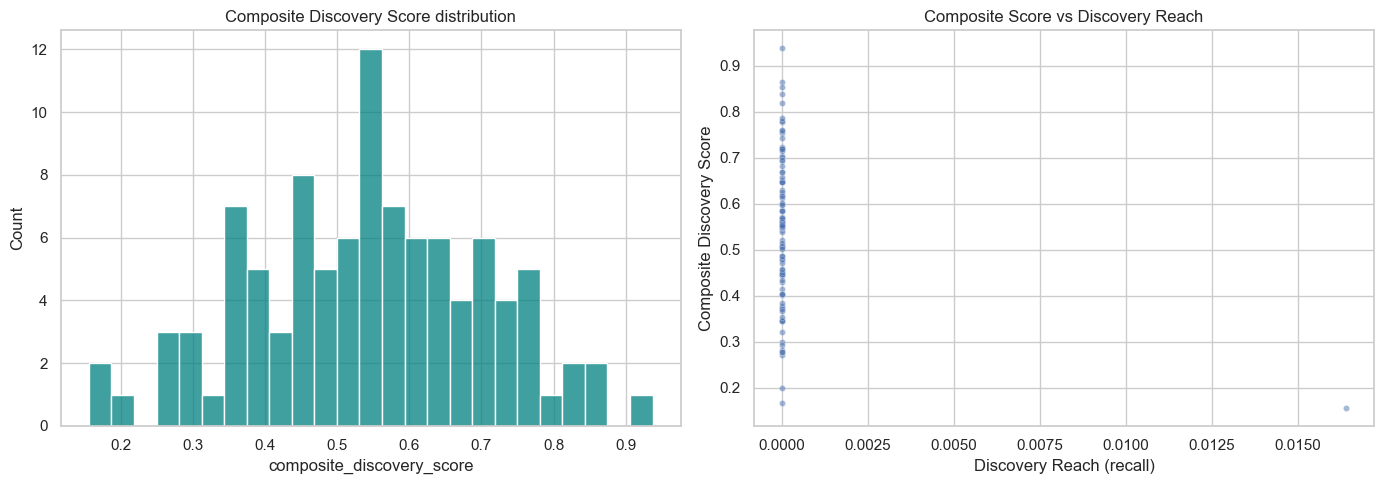

In [ ]:
composite_cols = ['artist_novelty', 'feature_exploration', 'intralist_diversity']
# These tend to be the most orthogonal based on typical correlation patterns

if len(metric_means) > 3:
    # Normalize each metric to [0,1] across users
    normed = metric_means[composite_cols].copy()
    for c in composite_cols:
        cmin, cmax = normed[c].min(), normed[c].max()
        if cmax > cmin:
            normed[c] = (normed[c] - cmin) / (cmax - cmin)
        else:
            normed[c] = 0.0

    normed['composite_discovery_score'] = normed[composite_cols].mean(axis=1)

    # Compare with discovery_reach as a proxy for Discovery@K
    normed['discovery_reach'] = metric_means['discovery_reach']

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.histplot(normed['composite_discovery_score'], bins=25, ax=axes[0], color='teal')
    axes[0].set_title('Composite Discovery Score distribution')

    sns.scatterplot(data=normed, x='discovery_reach', y='composite_discovery_score',
                    ax=axes[1], alpha=0.5, s=20)
    axes[1].set_title('Composite Score vs Discovery Reach')
    axes[1].set_xlabel('Discovery Reach (recall)')
    axes[1].set_ylabel('Composite Discovery Score')
    plt.tight_layout()

    r = normed[['composite_discovery_score', 'discovery_reach']].corr().iloc[0, 1]
    print(f'Correlation between composite score and discovery reach: {r:.3f}')
    print('If correlation is low, the composite captures something Discovery@K misses.')
else:
    print('Not enough data for composite score analysis.')


## 17) Expanded Recommendations

Building on Section 10's original recommendations, here are additional action items from the new analyses:


### For the train/eval gap (from Sections 12–13)
4. **Monitor per-user centroid drift** — users with high feature drift between train and eval periods are the hardest to serve; consider temporal weighting (upweight recent sessions)
5. **Artist overlap is a key predictor** — if eval-period artists rarely appear in training, the model needs better artist-agnostic features or collaborative signal
6. **Feature space listened-vs-catalog gap** — if listened tracks cluster tightly, negatives from the full catalog are too easy; consider in-distribution negative sampling

### For discovery metrics (from Sections 15–16)
7. **Artist Novelty Rate** captures a dimension `Discovery@K` misses — introducing new *artists* vs. new tracks from known artists
8. **Feature Space Exploration** directly measures adventurousness and can be used as a scoring component alongside sonic_fit, emotional_fit, and surprise
9. **Composite discovery score** (equal-weight average of artist novelty + feature exploration + intra-list diversity) is a candidate replacement or supplement for `Discovery@K`
10. **Anti-popularity validation**: popularity percentile of recs should be monitored in every experiment to ensure the core design principle holds
